In [65]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scqubits

In [3]:
EJ = 3
EJ_over_EL_list = np.linspace(2,30,51)
EJ_over_EC_list = np.linspace(2,10,41)

import pickle
with open('data_v4.data', 'rb') as f:
    (EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,
                 upside_down_phi_element01_array , upside_down_phi_element12_array ,
                   upside_down_freq01_array , upside_down_freq12_array ,
                     conventional_phi_element_array ,conventional_freq_array ,
                    upside_down_2nd_order_01_array ,upside_down_2nd_order_12_array ,conventional_2nd_order_array   ) = pickle.load(f)


hbar = 1/(2*np.pi)
def one_over_f_loss_rate(omega, EL, phi_element, one_over_f_flux_noise_amplitude):
    return_val = 8 * np.pi**3  # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val *= (phi_element)**2 / omega  # GHz
    return return_val

def dielectric_loss_rate(omega, EC, phi_element, Q_cap):
    temp_in_mK = 42  # K
    kB = 8.617333262e-5  # eV K−1
    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    return_val = hbar * omega**2  # h*GHZ^2
    return_val /= (4 * EC * Q_cap)  # GHZ
    return_val *= phi_element**2  # GHZ

    hbar_in_eVs = 6.5821e-16  # eV s
    coth_arg = beta * hbar_in_eVs * omega / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val *= 1 / np.tanh(coth_arg)  # GHZ
    return return_val

def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0
    return_val = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    return_val *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return_val = return_val**(-1/2)  # ns
    return return_val  # ns


In [37]:
# one_over_f_flux_noise_amplitude = 1e-6
Q_cap = 2.5e5

one_over_f_flux_noise_amplitude = 1e-6
# Q_cap = 1e6

Tphi = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
IFQ12_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
IFQ12_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

IFQ01_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
IFQ01_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

for i in range(len(EJ_over_EL_list)):
    for j in range(len(EJ_over_EC_list)):
        EL = EJ / EJ_over_EL_list[i]
        EC = EJ / EJ_over_EC_list[j]
        second_order_upside_down01 = upside_down_2nd_order_01_array[i, j]
        second_order_upside_down12 = upside_down_2nd_order_12_array[i, j]
        Tphi[i, j] = T_phi(second_order_upside_down01+second_order_upside_down12, 
                           one_over_f_flux_noise_amplitude)
        
        omega_IFQ12 = upside_down_freq12_array[i, j] * 2 * np.pi
        phi_upside_down12 = upside_down_phi_element12_array[i, j]
        IFQ12_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_IFQ12, EC, phi_upside_down12, Q_cap)
        IFQ12_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_IFQ12, EL, phi_upside_down12, one_over_f_flux_noise_amplitude)

        omega_IFQ01 = upside_down_freq01_array[i, j] * 2 * np.pi
        phi_upside_down01 = upside_down_phi_element01_array[i, j]
        IFQ01_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_IFQ01, EC, phi_upside_down01, Q_cap)
        IFQ01_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_IFQ01, EL, phi_upside_down01, one_over_f_flux_noise_amplitude)


T1ge = 2/(1/IFQ01_one_over_f_loss_lifetime + \
             1/IFQ01_dielectric_lifetime)/1e6 # milisecond
T1ef = 2/(1/IFQ12_one_over_f_loss_lifetime + \
             1/IFQ12_dielectric_lifetime)/1e6 # milisecond
Tphi =  Tphi / 1e6 # milisecond which is 1e-3 second

# to understand the orientation of imshow(): https://matplotlib.org/stable/users/explain/artists/imshow_extent.html

In [38]:
T1ef.shape

(51, 41)

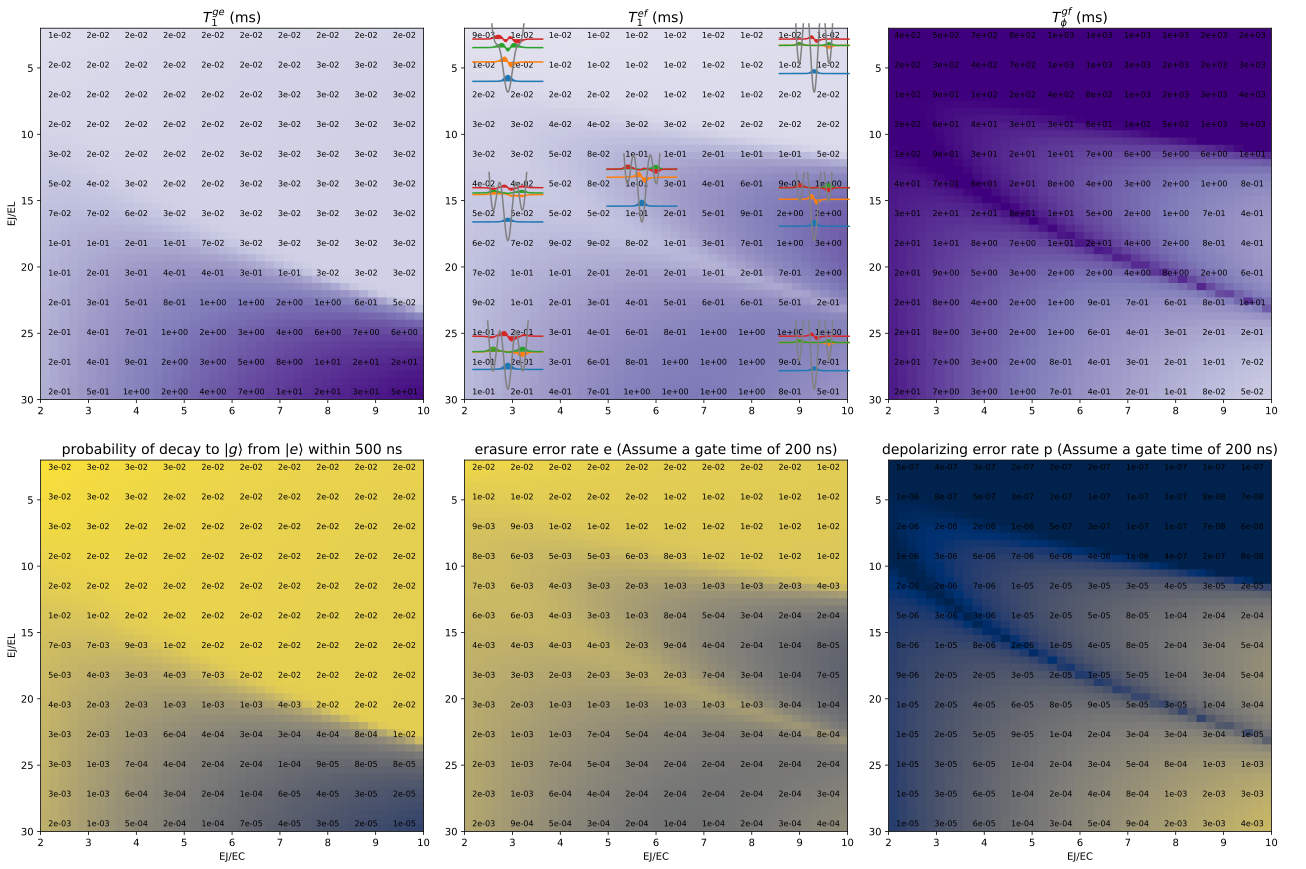

In [122]:
cmap_T = plt.get_cmap('Purples')
norm_T =  LogNorm(1e-3, 1e2)
cmap_p = plt.get_cmap('cividis')
norm_p =  LogNorm(1e-6, 5e-2)

fig = plt.figure(figsize = (19 ,12))

first_row_h_start = 0.54
second_row_h_start = 0.04
row_hspace = 0.43
ylabel_width = 0.03
heatmap_width = 0.28
heatmap_wspace = 0.03
ax0 = fig.add_axes([ylabel_width ,first_row_h_start, heatmap_width, row_hspace])
ax1 = fig.add_axes([ylabel_width + heatmap_width + heatmap_wspace, first_row_h_start, heatmap_width, row_hspace])
ax2 = fig.add_axes([ylabel_width + (heatmap_width + heatmap_wspace)*2, first_row_h_start, heatmap_width,row_hspace])
cbar_ax_T = fig.add_axes([-0.02+ (heatmap_width + heatmap_wspace)*3, first_row_h_start, 1- ylabel_width - (heatmap_width + heatmap_wspace)*3, row_hspace])
cbar_ax_T.axis('off')

ax3 = fig.add_axes([ylabel_width ,second_row_h_start, heatmap_width, row_hspace])
ax4 = fig.add_axes([ylabel_width + heatmap_width + heatmap_wspace, second_row_h_start, heatmap_width, row_hspace])
ax5 = fig.add_axes([ylabel_width + (heatmap_width + heatmap_wspace)*2, second_row_h_start, heatmap_width,row_hspace])
cbar_ax_p = fig.add_axes([-0.02+ (heatmap_width + heatmap_wspace)*3, second_row_h_start, 1- ylabel_width - (heatmap_width + heatmap_wspace)*3, row_hspace])
cbar_ax_p.axis('off')

for ax, data, title,norm,cmap in zip([ax0,ax1,ax2,ax3,ax4,ax5],
                            [T1ge,T1ef, Tphi,    500*1e-6/T1ge, 200*1e-6/T1ef,200*1e-6/Tphi], 
                            [rf'$T_1^{{ge}}$ (ms)', 
                                rf'$T_1^{{ef}}$ (ms)',  
                                rf'$T_\phi^{{gf}}$ (ms)',
                                rf'probability of decay to $|g\rangle$ from $|e\rangle$ within 500 ns', 
                                rf'erasure error rate e (Assume a gate time of 200 ns)', 
                                rf'depolarizing error rate p (Assume a gate time of 200 ns)'],
                            [norm_T,norm_T,norm_T,norm_p,norm_p,norm_p],
                            [cmap_T,cmap_T,cmap_T,cmap_p,cmap_p,cmap_p]):
    ax.set_title(title, y=1.0, size=14)
    im = ax.imshow(data, 
                   extent=[ 
                           
                           EJ_over_EC_list.min(), EJ_over_EC_list.max(),
                           EJ_over_EL_list.max(), EJ_over_EL_list.min(),
                            ],
                            origin="upper",
                   cmap=cmap, norm=norm, aspect='auto')
    

    for i in range(data.shape[0])[1::4]:
        for j in range(data.shape[1])[2::4]:
            ax.text(EJ_over_EC_list[j], 
                    EJ_over_EL_list[i],f"{data[i,j]:.0e}",ha='center',va='center',size=8)
ax0.set_ylabel("EJ/EL")
ax3.set_ylabel("EJ/EL")
ax3.set_xlabel("EJ/EC")
ax4.set_xlabel("EJ/EC")
ax5.set_xlabel("EJ/EC")






inset_ax = inset_axes(ax1, width="100%", height="100%", bbox_to_anchor=[0, 0.8, 0.2, 0.2], bbox_transform=ax1.transAxes,loc=3)
_, wavefunction_ax =  scqubits.Fluxonium(EJ = 3,EC = 3/3,EL = 3/4, cutoff = 110,flux = 0,truncated_dim=20).plot_wavefunction(which=[0,1,2,3], fig_ax=(fig, inset_ax))
wavefunction_ax.set_facecolor('none')
wavefunction_ax.axis('off')

inset_ax = inset_axes(ax1, width="100%", height="100%", bbox_to_anchor=[0, 0, 0.2, 0.2], bbox_transform=ax1.transAxes,loc=3)
_, wavefunction_ax =  scqubits.Fluxonium(EJ = 3,EC = 3/3,EL = 3/28, cutoff = 110,flux = 0,truncated_dim=20).plot_wavefunction(which=[0,1,2,3], fig_ax=(fig, inset_ax))
wavefunction_ax.set_facecolor('none')
wavefunction_ax.axis('off')

inset_ax = inset_axes(ax1, width="100%", height="100%", bbox_to_anchor=[0.8, 0, 0.2, 0.2], bbox_transform=ax1.transAxes,loc=3)
_, wavefunction_ax =  scqubits.Fluxonium(EJ = 3,EC = 3/9.3,EL = 3/28, cutoff = 110,flux = 0,truncated_dim=20).plot_wavefunction(which=[0,1,2,3], fig_ax=(fig, inset_ax))
wavefunction_ax.set_facecolor('none')
wavefunction_ax.axis('off')

inset_ax = inset_axes(ax1, width="100%", height="100%", bbox_to_anchor=[0.8, 0.8, 0.2, 0.2], bbox_transform=ax1.transAxes,loc=3)
_, wavefunction_ax =  scqubits.Fluxonium(EJ = 3,EC = 3/9.3,EL = 3/28, cutoff = 110,flux = 0,truncated_dim=20).plot_wavefunction(which=[0,1,2,3], fig_ax=(fig, inset_ax))
wavefunction_ax.set_facecolor('none')
wavefunction_ax.axis('off')

inset_ax = inset_axes(ax1, width="100%", height="100%", bbox_to_anchor=[0.8, 0.4, 0.2, 0.2], bbox_transform=ax1.transAxes,loc=3)
_, wavefunction_ax =  scqubits.Fluxonium(EJ = 3,EC = 3/9.3,EL = 3/15, cutoff = 110,flux = 0,truncated_dim=20).plot_wavefunction(which=[0,1,2,3], fig_ax=(fig, inset_ax))
wavefunction_ax.set_facecolor('none')
wavefunction_ax.axis('off')

inset_ax = inset_axes(ax1, width="100%", height="100%", bbox_to_anchor=[0, 0.4, 0.2, 0.2], bbox_transform=ax1.transAxes,loc=3)
_, wavefunction_ax =  scqubits.Fluxonium(EJ = 3,EC = 3/3,EL = 3/15, cutoff = 110,flux = 0,truncated_dim=20).plot_wavefunction(which=[0,1,2,3], fig_ax=(fig, inset_ax))
wavefunction_ax.set_facecolor('none')
wavefunction_ax.axis('off')

inset_ax = inset_axes(ax1, width="100%", height="100%", bbox_to_anchor=[0.35, 0.45, 0.2, 0.2], bbox_transform=ax1.transAxes,loc=3)
_, wavefunction_ax =  scqubits.Fluxonium(EJ = 3,EC = 3/5.7,EL = 3/13.5, cutoff = 110,flux = 0,truncated_dim=20).plot_wavefunction(which=[0,1,2,3], fig_ax=(fig, inset_ax))
wavefunction_ax.set_facecolor('none')
wavefunction_ax.axis('off')


# cbar_T = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm_T, cmap=cmap_T),ax=cbar_ax_T,  shrink=1, aspect=40, pad=0.02)
# cbar_T.set_label(rf'$ms$', size=12)
# cbar_p = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm_p, cmap=cmap_p),ax=cbar_ax_p,  shrink=1, aspect=40, pad=0.02)
# cbar_p.set_label(rf'$ms$', size=12)

plt.show()
fig.savefig('coherence_times.pdf')
